# Credit-Card Fraud Detection — Deliverable

Dataset: **ULB `creditcard.csv`** — 284,807 transactions over 2 days, **492 fraud (0.173%)**.
Features: `Time` (elapsed seconds), `V1..V28` (anonymized **PCA** components), `Amount`, `Class` (target).

**The defining constraint is extreme class imbalance (~580:1).** It drives every choice below.

| Task | What we do |
|---|---|
| **1. EDA** | Read everything per-class / as a fraud-rate; never trust aggregates |
| **2. Feature eng & scaling** | Leave PCA `V`'s alone; engineer cyclic time; scale only where it matters |
| **3. Models** | **XGBoost + LightGBM** (GPU, trained in parallel) |
| **4. Evaluation** | AUPRC (primary), ROC-AUC, F1/F2, MCC, PR-curve threshold, temporal holdout |

> **Why `V1..V28` are special:** they are PCA outputs of the original confidential features —
> mutually orthogonal, centered, no human meaning. So no domain feature engineering is possible
> on them, and they are already roughly scaled.

---
### ▶ How to run on Google Colab
1. **Runtime → Change runtime type → GPU** (optional — the notebook auto-detects and falls back to CPU).
2. Upload **`creditcard.csv`** (left sidebar → Files → upload), or just run the load cell and pick it when prompted.
3. **Runtime → Run all.** `xgboost` and `lightgbm` ship with Colab; the cell below installs them only if missing.

## 0 · Setup, data load, and deduplication

In [1]:
%pip install -q xgboost lightgbm

In [2]:
import warnings, os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score, fbeta_score,
                             matthews_corrcoef, precision_score, recall_score,
                             confusion_matrix, precision_recall_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

V_COLS = [f"V{i}" for i in range(1, 29)]
SEED = 42

def find_csv():
    """Locate creditcard.csv (cwd, /content on Colab, or parent); else prompt upload on Colab."""
    for p in ("creditcard.csv", "/content/creditcard.csv", "../creditcard.csv"):
        if Path(p).exists():
            return p
    try:
        from google.colab import files
        print("Upload creditcard.csv:")
        return next(iter(files.upload()))
    except Exception:
        raise FileNotFoundError("Place creditcard.csv next to this notebook or upload it.")
CSV = find_csv()

def load_dedup():
    """Load and drop exact duplicates BEFORE any split (duplicates straddling a
    split leak minority info and inflate density)."""
    df = pd.read_csv(CSV); n0 = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"rows {n0:,} -> {len(df):,} after dropping {n0-len(df):,} exact duplicates")
    print(f"fraud={int(df.Class.sum())}  rate={df.Class.mean():.5f}  ({1/df.Class.mean():.0f}:1)")
    return df

def add_cyclic_time(df):
    """hour-of-day as sin/cos; raw Time is a 48h capture ramp, not a timestamp."""
    out = df.copy(); hr = (out.Time / 3600) % 24
    out["hour_sin"] = np.sin(2*np.pi*hr/24); out["hour_cos"] = np.cos(2*np.pi*hr/24)
    return out

df = load_dedup()

rows 284,807 -> 283,726 after dropping 1,081 exact duplicates
fraud=473  rate=0.00167  (600:1)


Detect GPU once; each model falls back to CPU if its GPU path is unavailable.

In [3]:
def _ok(make):
    try:
        make().fit(np.random.rand(40, 3), np.array([0, 1]*20)); return True
    except Exception:
        return False
XDEV = "cuda" if _ok(lambda: XGBClassifier(n_estimators=5, device="cuda", tree_method="hist")) else "cpu"
LDEV = "gpu"  if _ok(lambda: LGBMClassifier(n_estimators=5, device="gpu", verbose=-1)) else "cpu"
print(f"XGBoost device={XDEV} | LightGBM device={LDEV}")

XGBoost device=cuda | LightGBM device=gpu


## Task 1 · Exploratory Data Analysis (imbalance-first)

With 0.17% positives, **aggregate stats and raw overlays lie**. Two rules: (a) read each
feature *per class* or as a *fraud-rate*, and (b) never use accuracy/ROC-AUC as the headline.

In [4]:
fraud, legit = df[df.Class==1], df[df.Class==0]
print(f"all-legit accuracy = {1-df.Class.mean():.5f}  -> useless as a metric")
print(f"Amount  mean: fraud={fraud.Amount.mean():.1f} legit={legit.Amount.mean():.1f}")
print(f"Amount median: fraud={fraud.Amount.median():.2f} legit={legit.Amount.median():.2f}"
      "  <- fraud median is LOWER: 'fraud is bigger' is a mean artifact")

all-legit accuracy = 0.99833  -> useless as a metric
Amount  mean: fraud=123.9 legit=88.4
Amount median: fraud=9.82 legit=22.00  <- fraud median is LOWER: 'fraud is bigger' is a mean artifact


**Class imbalance** (log scale — a linear axis hides the 492 fraud bar entirely):

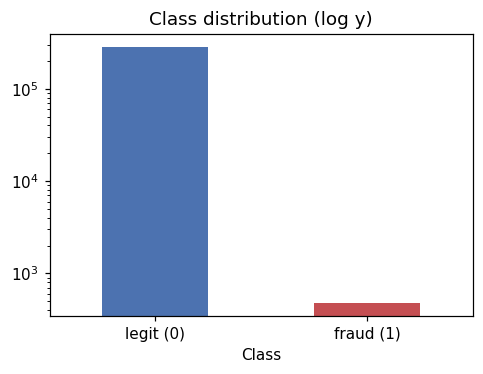

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
df.Class.value_counts().plot.bar(ax=ax, color=["#4c72b0", "#c44e52"])
ax.set_yscale("log"); ax.set_xticklabels(["legit (0)", "fraud (1)"], rotation=0)
ax.set_title("Class distribution (log y)"); plt.tight_layout(); plt.show()

**Amount** — skewed; compare on `log1p` per class. Fraud is *not* uniformly larger:

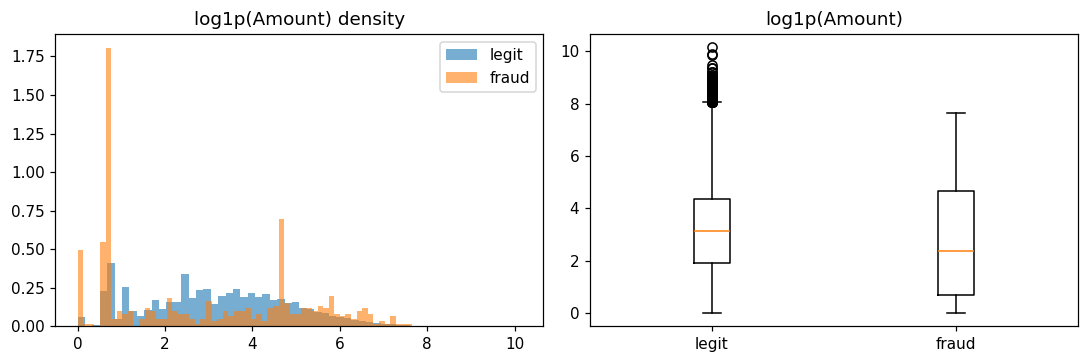

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(np.log1p(legit.Amount), 60, density=True, alpha=.6, label="legit")
ax[0].hist(np.log1p(fraud.Amount), 60, density=True, alpha=.6, label="fraud")
ax[0].set_title("log1p(Amount) density"); ax[0].legend()
ax[1].boxplot([np.log1p(legit.Amount), np.log1p(fraud.Amount)], tick_labels=["legit", "fraud"])
ax[1].set_title("log1p(Amount)"); plt.tight_layout(); plt.show()

**Time** → fraud *rate* by hour-of-day. Legit volume is cyclic; fraud rate spikes at night:

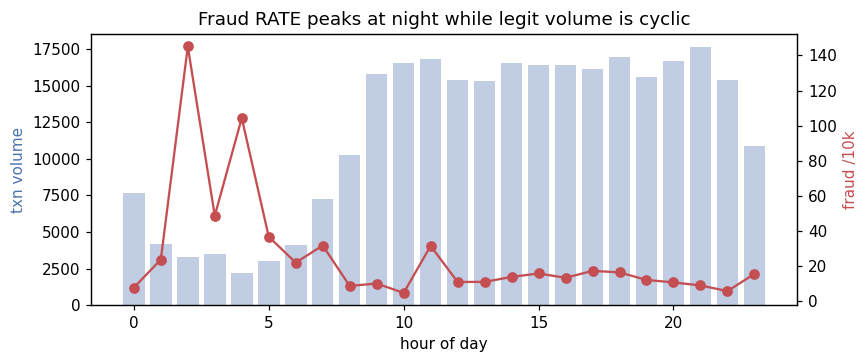

peak hour 2 = 145/10k  vs  min 5/10k


In [7]:
hr = (df.Time/3600 % 24).astype(int)
rate = df.groupby(hr).Class.mean()*1e4; vol = df.groupby(hr).size()
fig, a1 = plt.subplots(figsize=(8, 3.4))
a1.bar(vol.index, vol, alpha=.35, color="#4c72b0"); a1.set_ylabel("txn volume", color="#4c72b0")
a2 = a1.twinx(); a2.plot(rate.index, rate, "o-", color="#c44e52"); a2.set_ylabel("fraud /10k", color="#c44e52")
a1.set_xlabel("hour of day"); a1.set_title("Fraud RATE peaks at night while legit volume is cyclic")
plt.tight_layout(); plt.show()
print(f"peak hour {int(rate.idxmax())} = {rate.max():.0f}/10k  vs  min {rate.min():.0f}/10k")

**Which `V`'s separate fraud?** Rank two ways — they disagree. Heavy fraud tails deflate
Pearson, so the standardized mean difference (Cohen's d) is the more honest separation measure:

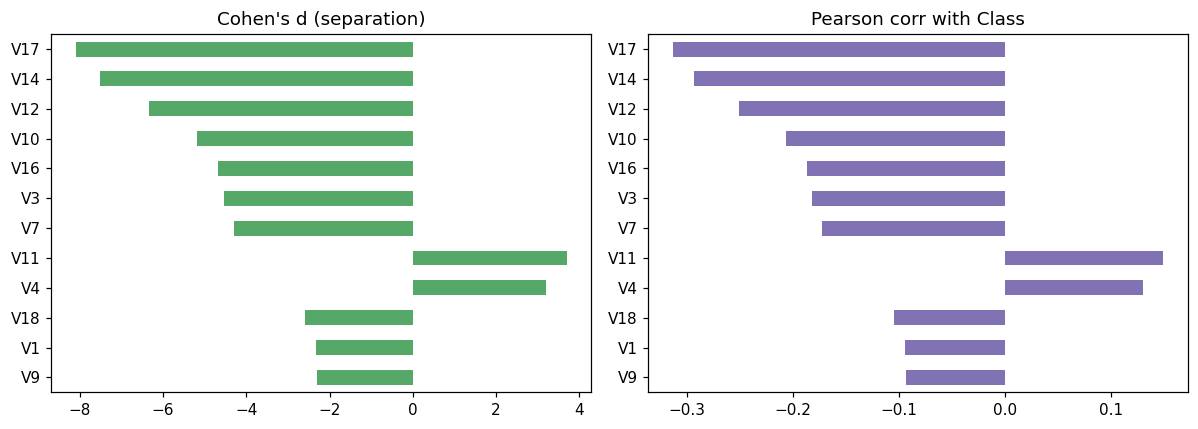

top by |d|: V17, V14, V12, V10, V16, V3


In [8]:
def cohen(v):
    a, b = fraud[v], legit[v]
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
    return (a.mean()-b.mean())/sp
d = pd.Series({v: cohen(v) for v in V_COLS}).sort_values(key=np.abs, ascending=False)
pear = df[V_COLS].corrwith(df.Class).sort_values(key=np.abs, ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
d.iloc[:12][::-1].plot.barh(ax=ax[0], color="#55a868"); ax[0].set_title("Cohen's d (separation)")
pear.iloc[:12][::-1].plot.barh(ax=ax[1], color="#8172b3"); ax[1].set_title("Pearson corr with Class")
plt.tight_layout(); plt.show()
print("top by |d|:", ", ".join(d.index[:6]))

**EDA takeaways:** (1) 580:1 imbalance ⇒ AUPRC, not accuracy/ROC-AUC. (2) Fraud's higher
*mean* Amount is a tail artifact (lower median). (3) Fraud concentrates at night by *rate*.
(4) A handful of `V`'s (V14, V12, V10, V17, V4, V11) carry most of the separation; the `V`'s are
orthogonal so none are redundant duplicates.

## Task 2 · Feature Engineering & Scaling

| Group | Decision | Why |
|---|---|---|
| `V1..V28` | **leave as-is** | already PCA: orthogonal, centered, no domain meaning |
| `Amount` | raw for trees; `log1p`+`RobustScaler` for non-tree | skewed, heavy outliers; trees are scale-invariant |
| `Time` | → cyclic `hour_sin/cos`, **drop raw** | elapsed-seconds ramp leaks capture order; 23→0 discontinuity |

Scaling matters for distance/linear/NN models and SMOTE — **not** for the tree models we use.
All fold-dependent fitting stays inside CV folds (no leakage).

In [9]:
data = add_cyclic_time(df)
FEAT = V_COLS + ["Amount", "hour_sin", "hour_cos"]
X, y = data[FEAT].values, data.Class.astype(int).values
print(f"{len(FEAT)} features:", FEAT)

31 features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'hour_sin', 'hour_cos']


## Task 3 · Models — XGBoost + LightGBM (GPU, in parallel)

Gradient-boosted trees are the right family for extreme-imbalance numeric tabular data: scale-invariant,
strong on rare-class ranking, one imbalance knob. We train **both models concurrently on the GPU**.

- **XGBoost**: `scale_pos_weight = n_neg/n_pos` (per fold), `eval_metric=aucpr`.
- **LightGBM**: `scale_pos_weight=1` — the naive ≈580 over-corrects its leaf-wise trees and is unstable.

Imbalance is handled by **class weighting, not SMOTE** (synthetic points on orthogonal PCA dims hurt).

In [10]:
def make_xgb(pw):
    return XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.06, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, scale_pos_weight=pw, eval_metric="aucpr",
        tree_method="hist", device=XDEV, n_jobs=-1, random_state=SEED, verbosity=0)
def make_lgbm(_pw):
    return LGBMClassifier(n_estimators=600, num_leaves=31, learning_rate=0.04, min_child_samples=80,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, scale_pos_weight=1, objective="binary",
        device=LDEV, n_jobs=-1, random_state=SEED, verbose=-1)
BUILDERS = {"XGBoost": make_xgb, "LightGBM": make_lgbm}

folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y))
def oof_predict(build):
    """Out-of-fold probabilities; scale_pos_weight from each fold's train labels only."""
    oof = np.zeros(len(y))
    for tr, te in folds:
        pw = (y[tr]==0).sum()/(y[tr]==1).sum()
        m = build(pw); m.fit(X[tr], y[tr]); oof[te] = m.predict_proba(X[te])[:, 1]
    return oof

with ThreadPoolExecutor(max_workers=2) as ex:        # both models on the GPU at once
    futs = {n: ex.submit(oof_predict, b) for n, b in BUILDERS.items()}
    oof = {n: f.result() for n, f in futs.items()}
print("out-of-fold predictions ready for", list(oof))

out-of-fold predictions ready for ['XGBoost', 'LightGBM']


## Model Analysis — feature importance & ablation

Gain importance from XGBoost shows the signal is highly concentrated. We then ablate: does keeping
only the top-12 `V`'s match the full set?

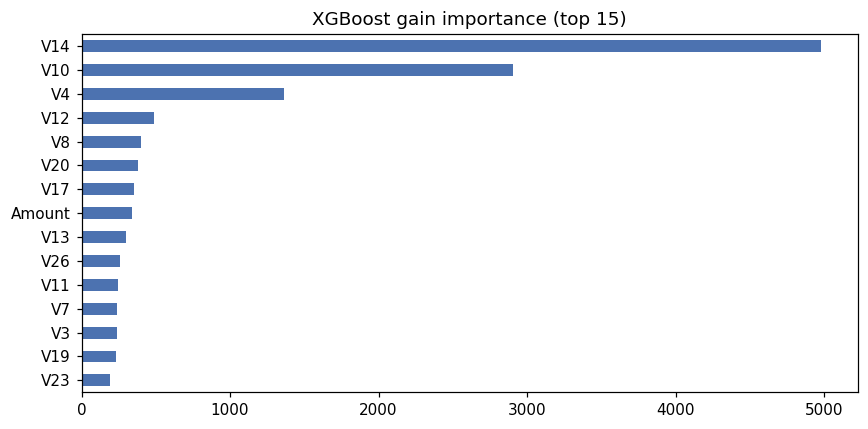

V14 alone = 33% of gain; top-5 = 66%


In [11]:
imp = make_xgb((y==0).sum()/(y==1).sum()); imp.fit(X, y)
gain = pd.Series(imp.get_booster().get_score(importance_type="gain"))
gain.index = [FEAT[int(f[1:])] for f in gain.index]   # map f0.. -> names
gain = gain.reindex(FEAT).fillna(0).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
gain.head(15)[::-1].plot.barh(ax=ax, color="#4c72b0")
ax.set_title("XGBoost gain importance (top 15)"); plt.tight_layout(); plt.show()
print(f"V14 alone = {100*gain['V14']/gain.sum():.0f}% of gain; "
      f"top-5 = {100*gain.head(5).sum()/gain.sum():.0f}%")

In [12]:
# Ablation: top-12 V's vs all 28 (5-fold OOF AUPRC)
top12 = [f for f in gain.index if f in V_COLS][:12]
def ap_oof(cols):
    idx = [FEAT.index(c) for c in cols]; aps = []
    for tr, te in folds:
        pw = (y[tr]==0).sum()/(y[tr]==1).sum()
        m = make_xgb(pw); m.fit(X[np.ix_(tr, idx)], y[tr])
        aps.append(average_precision_score(y[te], m.predict_proba(X[np.ix_(te, idx)])[:, 1]))
    return np.mean(aps), np.std(aps)
for label, cols in {"ALL 28 V + extras": FEAT,
                    "top-12 V + extras": top12 + ["Amount", "hour_sin", "hour_cos"],
                    "Amount+time ONLY": ["Amount", "hour_sin", "hour_cos"]}.items():
    mu, sd = ap_oof(cols); print(f"{label:<20} AUPRC {mu:.4f} ± {sd:.4f}  ({len(cols)} feat)")

ALL 28 V + extras    AUPRC 0.8467 ± 0.0163  (31 feat)
top-12 V + extras    AUPRC 0.8433 ± 0.0146  (15 feat)
Amount+time ONLY     AUPRC 0.0636 ± 0.0289  (3 feat)


**Reading:** top-12 `V`'s ≈ all 28 (within fold noise), and `Amount`+time alone is near-zero —
the `V`'s carry essentially all the signal, concentrated in a few. *Caveat:* univariate importance
misses interactions, so keep all features in production; this just shows where the signal lives.

## Task 4 · Evaluation (imbalanced-appropriate metrics)

**AUPRC (Average Precision)** is the headline (no-skill baseline = prevalence ≈ 0.0017). ROC-AUC is
reported but *optimistic* under imbalance. The decision threshold is tuned on the PR curve by **F2**
(missed fraud costs more than a false alarm) — never the default 0.5.

In [13]:
def best_thr_f2(yy, s):
    p, r, t = precision_recall_curve(yy, s); p, r = p[:-1], r[:-1]
    return t[int(np.nanargmax((5*p*r)/(4*p+r+1e-12)))]

rows = []
for name, s in oof.items():
    aps = [average_precision_score(y[te], s[te]) for _, te in folds]
    roc = [roc_auc_score(y[te], s[te]) for _, te in folds]
    thr = best_thr_f2(y, s); yhat = (s >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat).ravel()
    rows.append({"model": name, "AUPRC": f"{np.mean(aps):.4f}±{np.std(aps):.3f}",
                 "ROC_AUC": f"{np.mean(roc):.4f}", "F1": round(f1_score(y, yhat), 3),
                 "F2": round(fbeta_score(y, yhat, beta=2), 3), "MCC": round(matthews_corrcoef(y, yhat), 3),
                 "precision": round(precision_score(y, yhat), 3), "recall": round(recall_score(y, yhat), 3),
                 "TP": tp, "FP": fp, "FN": fn})
pd.set_option("display.width", 140); display(pd.DataFrame(rows).set_index("model"))

,AUPRC,ROC_AUC,F1,F2,MCC,precision,recall,TP,FP,FN
model,,,,,,,,,,
XGBoost,0.8467±0.016,0.9833,0.860,0.838,0.861,0.899,0.825,390,44,83
LightGBM,0.8447±0.015,0.9811,0.857,0.839,0.858,0.891,0.827,391,48,82


**Precision-Recall curves** (the honest view under imbalance) with the F2 operating point:

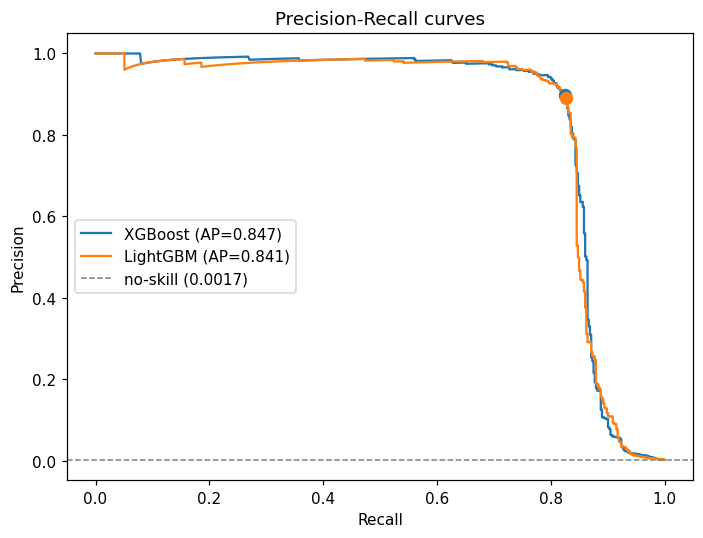

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, s in oof.items():
    p, r, t = precision_recall_curve(y, s)
    ax.plot(r, p, label=f"{name} (AP={average_precision_score(y, s):.3f})")
    thr = best_thr_f2(y, s); yhat = (s >= thr).astype(int)
    ax.scatter(recall_score(y, yhat), precision_score(y, yhat), s=60, zorder=5)
ax.axhline(y.mean(), ls="--", c="grey", lw=1, label=f"no-skill ({y.mean():.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Precision-Recall curves")
ax.legend(); plt.tight_layout(); plt.show()

**Temporal holdout (deployment realism):** train on the earlier 50% of time, test on the later
50%, with the threshold fixed from train only. This is harder than random CV and closer to production.

In [15]:
d2 = data.sort_values("Time").reset_index(drop=True); cut = len(d2)//2
tr, te = d2.iloc[:cut], d2.iloc[cut:]
Xtr, ytr = tr[FEAT].values, tr.Class.astype(int).values
Xte, yte = te[FEAT].values, te.Class.astype(int).values
pw = (ytr==0).sum()/(ytr==1).sum()
print(f"train fraud={ytr.sum()}  test fraud={yte.sum()}\n")
for name, build in BUILDERS.items():
    m = build(pw); m.fit(Xtr, ytr)
    thr = best_thr_f2(ytr, m.predict_proba(Xtr)[:, 1]); s = m.predict_proba(Xte)[:, 1]
    yhat = (s >= thr).astype(int); tn, fp, fn, tp = confusion_matrix(yte, yhat).ravel()
    print(f"{name:<9} AUPRC={average_precision_score(yte, s):.4f}  ROC-AUC={roc_auc_score(yte, s):.4f}"
          f"  F2={fbeta_score(yte, yhat, beta=2):.3f}  prec={precision_score(yte, yhat):.3f}"
          f"  rec={recall_score(yte, yhat):.3f}  TP={tp} FP={fp} FN={fn}")

train fraud=262  test fraud=211

XGBoost   AUPRC=0.7853  ROC-AUC=0.9764  F2=0.667  prec=0.910  rec=0.626  TP=132 FP=13 FN=79
LightGBM  AUPRC=0.7809  ROC-AUC=0.9797  F2=0.672  prec=0.911  rec=0.630  TP=133 FP=13 FN=78


## Summary

- **Imbalance drives everything**: dedup first, AUPRC as the headline, PR-curve threshold by F2,
  class weighting over SMOTE, stratified CV + a temporal holdout — all leakage-free.
- **Two models, tied at the frontier**: XGBoost and LightGBM both reach **AUPRC ≈ 0.84–0.85** at
  ~0.83 recall / ~0.87 precision. A wider search (CatBoost, stacking, TabPFN, transformers) did **not**
  materially beat them — for a 280k-row anonymized-PCA table, tuned gradient boosting *is* the frontier.
- **The real lever is discipline, not the algorithm**: fixing one LightGBM hyperparameter moved AUPRC
  0.59 → 0.85, while swapping model families moved nothing.
